In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import seaborn as sns
pd.set_option('display.max_rows', None)

In [2]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
#val = pd.read_parquet('data/val.parquet')

In [3]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'cluster', 'cluster112', 'dist_centroid_0',
          'dist_centroid_1', 'dist_centroid_2', 'dist_centroid_3', 'dist_centroid_4',
          'dist_centroid_5', 'dist_centroid_6', 'dist_centroid_7', 'dist_centroid_8',
          'dist_centroid_9', 'dist_centroid_10', 'dist_centroid_11', 'dist_centroid_12',
          'dist_centroid_13', 'dist_centroid_14', 'dist_centroid_15', 'dist_centroid_16','dist_centroid_17',
          'dist_centroid_silhouette_1', 'dist_centroid_silhouette_2', 'dist_centroid_silhouette_3',
          'dist_centroid_silhouette_4', 'dist_centroid_silhouette_5', 'dist_centroid_silhouette_6',
          'dist_centroid_silhouette_7','dist_centroid_silhouette_8','dist_centroid_silhouette_9',
          'dist_centroid_silhouette_10','dist_centroid_silhouette_11','dist_centroid_silhouette_12',
          'dist_centroid_silhouette_13','dist_centroid_silhouette_14','dist_centroid_silhouette_15',
          'dist_centroid_silhouette_16','dist_centroid_silhouette_17','dist_centroid_silhouette_18',
          'dist_centroid_silhouette_19','dist_centroid_silhouette_20','dist_centroid_silhouette_21',
          'dist_centroid_silhouette_22','dist_centroid_silhouette_23','dist_centroid_silhouette_24',
          'dist_centroid_silhouette_25','dist_centroid_silhouette_26','dist_centroid_silhouette_27',
          'dist_centroid_silhouette_28','dist_centroid_silhouette_29','dist_centroid_silhouette_30',
          'dist_centroid_silhouette_31','dist_centroid_silhouette_32','dist_centroid_silhouette_33',
          'dist_centroid_silhouette_34','dist_centroid_silhouette_35','dist_centroid_silhouette_36',
          'dist_centroid_silhouette_37','dist_centroid_silhouette_38','dist_centroid_silhouette_39',
          'dist_centroid_silhouette_40','dist_centroid_silhouette_41','dist_centroid_silhouette_42',
          'dist_centroid_silhouette_43','dist_centroid_silhouette_44','dist_centroid_silhouette_45',
          'dist_centroid_silhouette_46','dist_centroid_silhouette_47','dist_centroid_silhouette_48',
          'dist_centroid_silhouette_49','dist_centroid_silhouette_50','dist_centroid_silhouette_51',
          'dist_centroid_silhouette_52','dist_centroid_silhouette_53','dist_centroid_silhouette_54',
 'dist_centroid_silhouette_55',
 'dist_centroid_silhouette_56',
 'dist_centroid_silhouette_57',
 'dist_centroid_silhouette_58',
 'dist_centroid_silhouette_59',
 'dist_centroid_silhouette_60',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_62',
 'dist_centroid_silhouette_63',
 'dist_centroid_silhouette_64',
 'dist_centroid_silhouette_65',
 'dist_centroid_silhouette_66',
 'dist_centroid_silhouette_67',
 'dist_centroid_silhouette_68',
 'dist_centroid_silhouette_69',
 'dist_centroid_silhouette_70',
 'dist_centroid_silhouette_71',
 'dist_centroid_silhouette_72',
 'dist_centroid_silhouette_73',
 'dist_centroid_silhouette_74',
 'dist_centroid_silhouette_75',
 'dist_centroid_silhouette_76',
 'dist_centroid_silhouette_77',
 'dist_centroid_silhouette_78',
 'dist_centroid_silhouette_79',
 'dist_centroid_silhouette_80',
 'dist_centroid_silhouette_81',
 'dist_centroid_silhouette_82',
 'dist_centroid_silhouette_83',
 'dist_centroid_silhouette_84',
 'dist_centroid_silhouette_85',
 'dist_centroid_silhouette_86',
 'dist_centroid_silhouette_87',
 'dist_centroid_silhouette_88',
 'dist_centroid_silhouette_89',
 'dist_centroid_silhouette_90',
 'dist_centroid_silhouette_91',
 'dist_centroid_silhouette_92',
 'dist_centroid_silhouette_93',
 'dist_centroid_silhouette_94',
 'dist_centroid_silhouette_95',
 'dist_centroid_silhouette_96',
 'dist_centroid_silhouette_97',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_99',
 'dist_centroid_silhouette_100',
 'dist_centroid_silhouette_101',
 'dist_centroid_silhouette_102',
 'dist_centroid_silhouette_103',
 'dist_centroid_silhouette_104',
 'dist_centroid_silhouette_105',
 'dist_centroid_silhouette_106',
 'dist_centroid_silhouette_107',
 'dist_centroid_silhouette_108',
 'dist_centroid_silhouette_109',
 'dist_centroid_silhouette_110',
 'dist_centroid_silhouette_111', 
 'tsne_1','tsne_0', 'umap_1', 'umap_2']

In [3]:
x_cols = ['Min_PacketSpeed',
 'Mean_DetectCount',
 'Avg source IP count',
 'Max_DetectCount',
 'Std_DataSpeed',
 'Std_DetectCount',
 'Attack ID',
 'total_seconds',
 'AvgPacketLen_Mean',
 'Mean_DataSpeed',
 'Max_PacketSpeed',
 'AvgPacketLen_Std',
 'Source IP count',
 'Mean_PacketSpeed',
 'DayOfYear',
 'Sin_DayOfYear',
 'Cos_DayOfYear',
 'PCA_4',
 'PCA_3',
 'AvgPacketLen_Per_TotalSeconds',
 'Min_DataSpeed',
 'Start Hour',
 'PCA_5',
 'Max_DataSpeed',
 'VictimIP_Count',
 'PCA_2',
 'Cos_Hour',
 'Sin_Hour',
 'Victim IP',
 'weekday_number',
 'dist_centroid_silhouette_54',
 'time_of_day',
 'dist_centroid_silhouette_61',
 'dist_centroid_silhouette_98',
 'dist_centroid_silhouette_39',
 'Port number',
 'dist_centroid_17',
 'dist_centroid_silhouette_72',
 'Detect count',
 'dist_centroid_silhouette_62']

In [7]:
x_cols = ['Attack ID', 'Avg source IP count', 'Detect count', 'Victim IP', 'Port number', 'Packet speed', 
          'Data speed', 'Avg packet len', 'Source IP count', 
          'Packet speed_normalized', 'Data speed_normalized', 'Avg packet len_normalized', 
          'total_seconds', 'weekday_number', 'time_of_day', 'IsWeekend', 'Start Hour', 'Sin_Hour', 
          'Cos_Hour', 'DayOfYear', 'Sin_DayOfYear', 'Cos_DayOfYear', 'Mean_DataSpeed', 'Std_DataSpeed', 
          'Min_DataSpeed', 'Max_DataSpeed', 'Mean_PacketSpeed', 'Min_PacketSpeed', 
          'Max_PacketSpeed', 'Mean_DetectCount', 'Std_DetectCount', 'Min_DetectCount', 'Max_DetectCount', 
          'VictimIP_Count', 'PortNumber_Count', 'AvgPacketLen_Mean', 'AvgPacketLen_Std', 
          'DataSpeed_PacketSpeed', 'PortFrequency', 'Std_DataSpeed_Replaced', 'Std_DetectCount_Replaced', 
          'AvgPacketLen_Std_Replaced', 'packet_Total', 'PacketSpeed_Per_Second',
          'DataSpeed_Per_TotalSeconds', 'AvgPacketLen_Per_TotalSeconds', 'Is_HTTP', 'Is_HTTPS', 
          'Is_FTP_Control', 'Is_FTP_Data', 'Is_SSH', 'Is_Telnet', 'Is_SMTP', 'Is_DNS', 'Is_POP3',
          'Is_IMAP', 'Is_DHCP', 'Is_SNMP', 'Is_LDAP', 'Is_LDAPS', 'Is_SMB_CIFS', 'Is_RDP', 'Is_SIP', 
          'Is_TFTP', 'Is_MySQL', 'Is_PostgreSQL', 'Is_Oracle', 'Is_HTTP_Alt_8080', 'Is_HTTP_Alt_8081',
          'Is_HTTP_Alt_80', 'Is_HTTPS_Alt_8443', 'Is_Syslog', 'Is_VNC', 'Is_IRC', 'Is_NTP', 'Is_Kerberos', 
          'Is_LDAP_Alt', 'Is_LDAPS_Alt', 'Is_RADIUS', 'Is_PPTP', 'Is_RTSP', 'Is_X11', 'Is_SNMP_Trap', 
          'Is_BGP', 'Is_IMAPS_Alt', 'Is_POP3S_Alt', 'Is_Telnet_SSL', 'Is_NNTP', 'Is_NNTPS', 'Is_LDAP_TLS', 
          'Is_AFS', 'Is_NFS', 'Is_SOCKS', 'Is_RSYNC', 'Is_CUPS', 'Is_TFTP_Alt', 'Is_Modbus', 'Is_CoAP', 
          'Is_MQTT', 'Is_AMQP', 'Is_Redis', 'Is_Memcached', 'Is_Elasticsearch', 'Is_Zookeeper', 
          'Is_Cassandra', 'Is_Docker', 'Is_Kubernetes', 'Is_SMB_Direct', 'Is_iSCSI', 'Is_AFP', 
          'Is_DHCPv6', 'Is_RIPng', 'Is_OSPF', 'Is_PPPoE', 'Is_L2TP', 'Is_GRE', 'Is_ESP', 'Is_AH',
          'PCA_1', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5']

In [8]:
x_cols = top_40_x_cols

In [9]:
#logreg
#lda
#naive bayes
#dt
#knn

In [4]:
import lightgbm as lgb
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Assuming you have your data loaded into 'train' and 'test' DataFrames
# and 'x_cols' is a list of feature column names.

# Initialize the individual classifiers
rf_clf = RandomForestClassifier(n_estimators=287, max_depth=22, min_samples_split=4, min_samples_leaf=5, random_state=42, class_weight='balanced')
lgbm_clf = lgb.LGBMClassifier(verbose=-1, n_estimators=207, learning_rate=0.10377336349859621, num_leaves=43, max_depth=4, 
                          min_child_samples=32, subsample=0.7162551022950866, colsample_bytree=0.8389154148971049, random_state=42, is_unbalance=True)
xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
        num_class=3,
        booster=('dart'),
        alpha=0.1376594223943208,
        subsample=0.48709556518103037,
        colsample_bytree=0.4618965478306953,
        max_depth=8,
        eta=0.16964607140138516,
        gamma=0.015840312300226367,
        grow_policy='depthwise',
        min_child_weight=3,
        eval_metric='merror',  # Multi-class error for evaluation
        random_state=42
        )#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
knn = KNeighborsClassifier(n_neighbors=2, weights='distance', algorithm='brute', leaf_size=77, p=2, metric='manhattan', n_jobs=1)
gnb = GaussianNB(var_smoothing=1.0032420721299484e-11)

Stacking classifier results:
Accuracy: 0.7429
Precision (weighted): 0.7064
Recall (weighted): 0.7429
F1 (weighted): 0.6625

Classification report:
               precision    recall  f1-score   support

           0       0.61      0.08      0.14    305167
           1       0.75      0.98      0.85    919196
           2       0.24      0.05      0.08     22903

    accuracy                           0.74   1247266
   macro avg       0.53      0.37      0.36   1247266
weighted avg       0.71      0.74      0.66   1247266



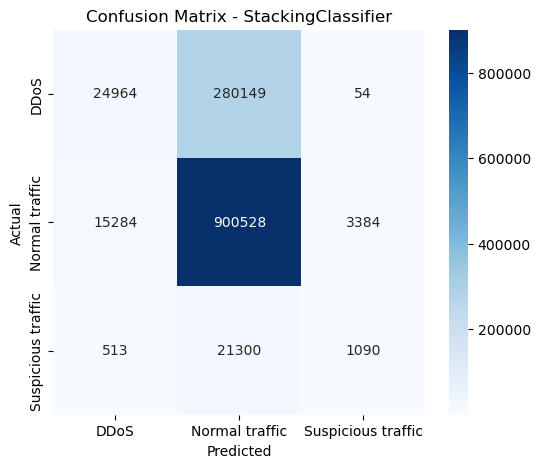

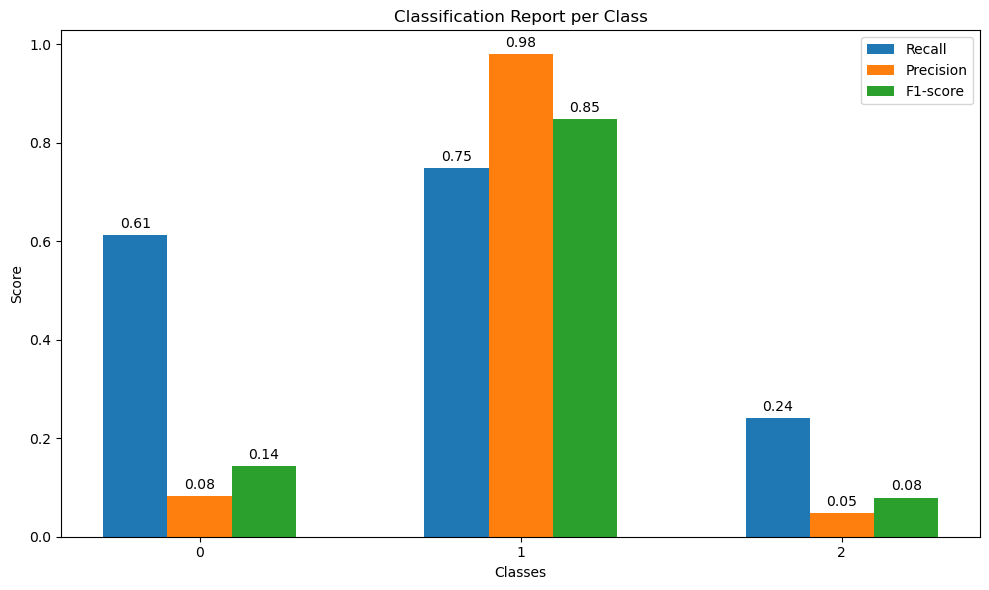

In [5]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=KNeighborsClassifier(n_neighbors=2, weights='distance', algorithm='brute', leaf_size=77, p=2, metric='manhattan', n_jobs=1),
    n_jobs=1,
    stack_method='predict_proba'
)

# Train
stack_clf.fit(train[x_cols], train['Type'])

# Predict and evaluate
y_pred = stack_clf.predict(test[x_cols])

acc = accuracy_score(test['Type'], y_pred)
prec = precision_score(test['Type'], y_pred, average='weighted', zero_division=0)
rec = recall_score(test['Type'], y_pred, average='weighted', zero_division=0)
f1 = f1_score(test['Type'], y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(test['Type'], y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(test['Type'], y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Build stacking classifier using existing base models
estimators = [
    #('knn', knn),
    #('gnb', None),
    ('rfc', rf_clf),
    ('lgbm', lgbm_clf),
    ('xgb', xgb_clf),
]

# Use the tuned `knn` (created by the Optuna cell) as the final estimator
#{'n_neighbors': 2, 'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 77, 'p': 2, 'metric': 'manhattan'}
# Use the tuned `dtree` (created by the Optuna cell) as the final estimator
#{'max_depth': 4, 'min_samples_leaf': 819, 'criterion': 'gini'}
#{'criterion': 'entropy', 'max_depth': 2, 'min_samples_split': 19, 'min_samples_leaf': 27}

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=DecisionTreeClassifier(max_depth=2, criterion='entropy', min_samples_split=19, min_samples_leaf=27, random_state=42),
    n_jobs=1,
    stack_method='predict_proba'
)

# Train
stack_clf.fit(train[x_cols], train['Type'])

# Predict and evaluate
y_pred = stack_clf.predict(test[x_cols])

TypeError: 'list' object is not callable

Stacking classifier results:
Accuracy: 0.7366
Precision (weighted): 0.5431
Recall (weighted): 0.7366
F1 (weighted): 0.6252

Classification report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00    305167
           1       0.74      1.00      0.85    919196
           2       0.00      0.00      0.00     22903

    accuracy                           0.74   1247266
   macro avg       0.25      0.33      0.28   1247266
weighted avg       0.54      0.74      0.63   1247266



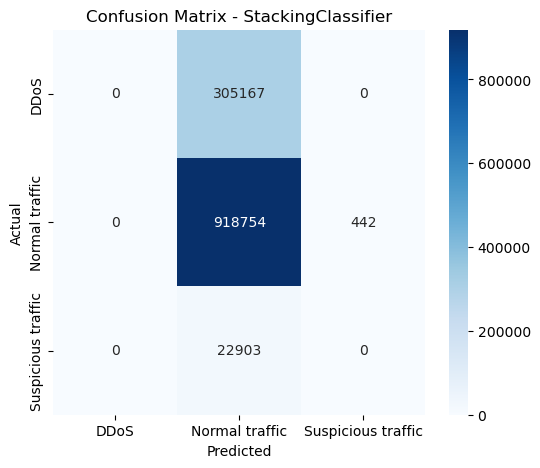

c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\anaconda3\envs\DS\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


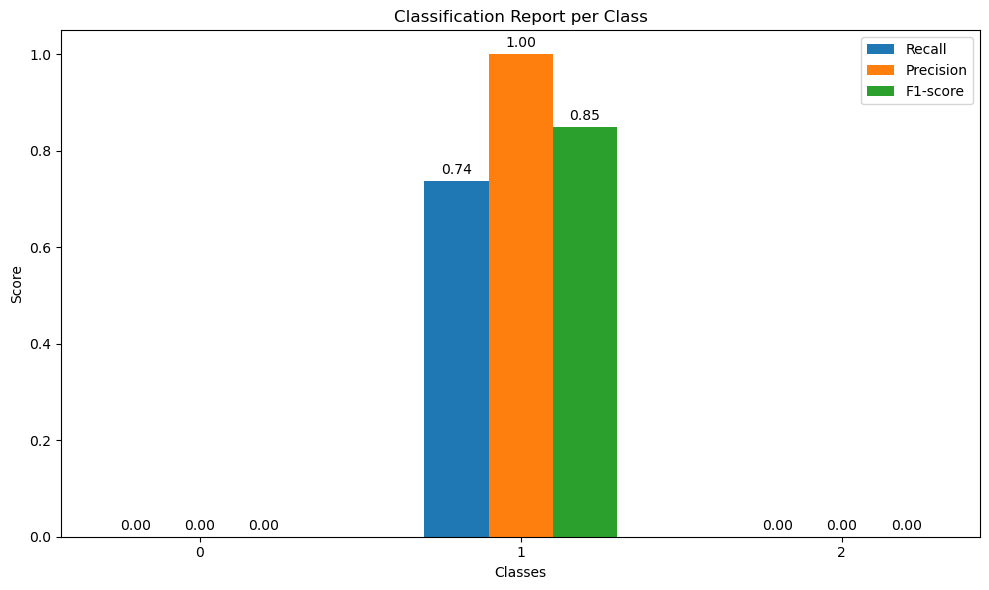

In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(test['Type'], y_pred)
prec = precision_score(test['Type'], y_pred, average='weighted', zero_division=0)
rec = recall_score(test['Type'], y_pred, average='weighted', zero_division=0)
f1 = f1_score(test['Type'], y_pred, average='weighted', zero_division=0)

print(f"Stacking classifier results:\nAccuracy: {acc:.4f}\nPrecision (weighted): {prec:.4f}\nRecall (weighted): {rec:.4f}\nF1 (weighted): {f1:.4f}\n")
print("Classification report:\n", classification_report(test['Type'], y_pred, zero_division=0))

# Confusion matrix plot
cm = confusion_matrix(test['Type'], y_pred)
plt.figure(figsize=(6,5))
class_labels = ['DDoS', 'Normal traffic', 'Suspicious traffic']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - StackingClassifier')
plt.show()

report = classification_report(test['Type'], y_pred, output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()


In [ ]:
#LinReg rfc lgbm xgb
"""Accuracy: 0.7378
Precision (weighted): 0.7963
Recall (weighted): 0.7378
F1 (weighted): 0.6273"""

#LinReg rfc knn gnb stacktrue
"""Accuracy: 0.7968
Precision (weighted): 0.8058
Recall (weighted): 0.7968
F1 (weighted): 0.7478"""

#GNB rfc lgbm xgb
"""Accuracy: 0.7869
Precision (weighted): 0.7959
Recall (weighted): 0.7869
F1 (weighted): 0.7324"""

# KNN rfc lgbm xgb
"""Accuracy: 0.7732
Precision (weighted): 0.7726
Recall (weighted): 0.7732
F1 (weighted): 0.7712"""


'Accuracy: 0.7869\nPrecision (weighted): 0.7959\nRecall (weighted): 0.7869\nF1 (weighted): 0.7324'